Shape: (145460, 23)
Shape after cleaning: (142193, 23)
Remaining nulls: 0
        Date     Month  Season
0 2008-12-01  December  Summer
1 2008-12-02  December  Summer
2 2008-12-03  December  Summer
3 2008-12-04  December  Summer
4 2008-12-05  December  Summer
           TempRange  HumidityChange  PressureChange
count  142193.000000   142193.000000   142193.000000
mean       11.039800      -17.362493       -2.395979
std         4.969307       16.335167        1.902968
min       -14.700000      -91.000000      -26.500000
25%         7.200000      -28.000000       -3.600000
50%        10.500000      -17.000000       -2.400000
75%        14.500000       -6.000000       -1.500000
max        31.400000       91.000000       20.300000
Shape after dropping Date: (142193, 27)
Remaining columns: ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressur

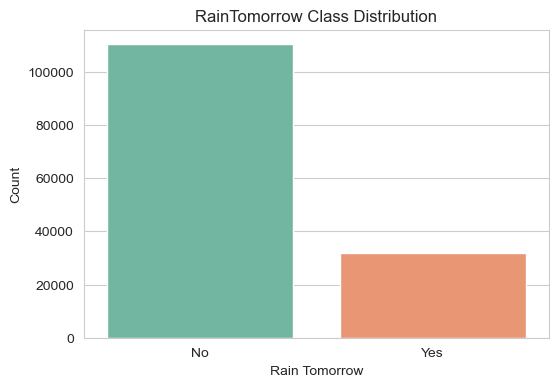

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


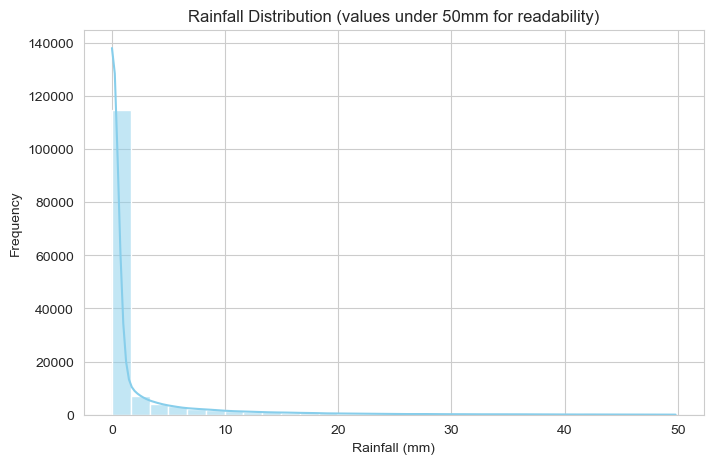

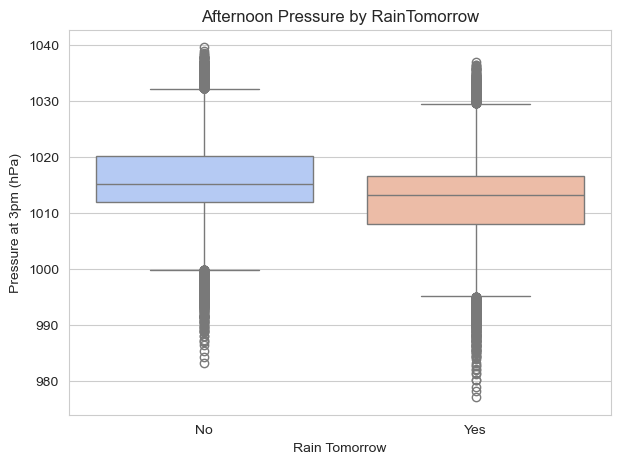

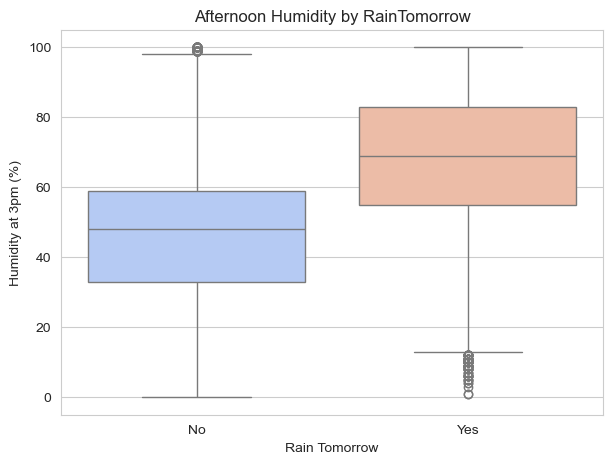

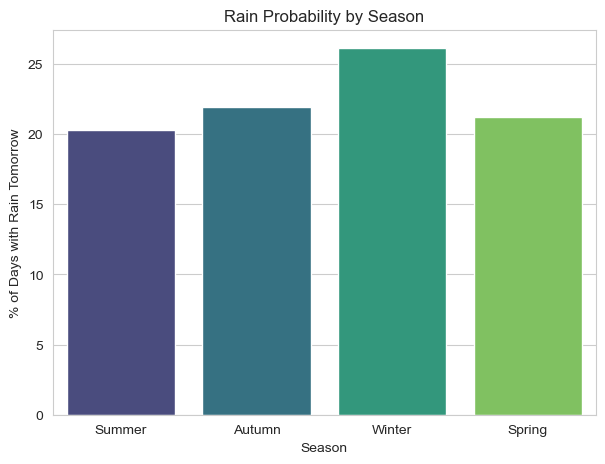

Season
Summer    20.303013
Autumn    21.886782
Winter    26.120234
Spring    21.242415
Name: RainTomorrow, dtype: float64


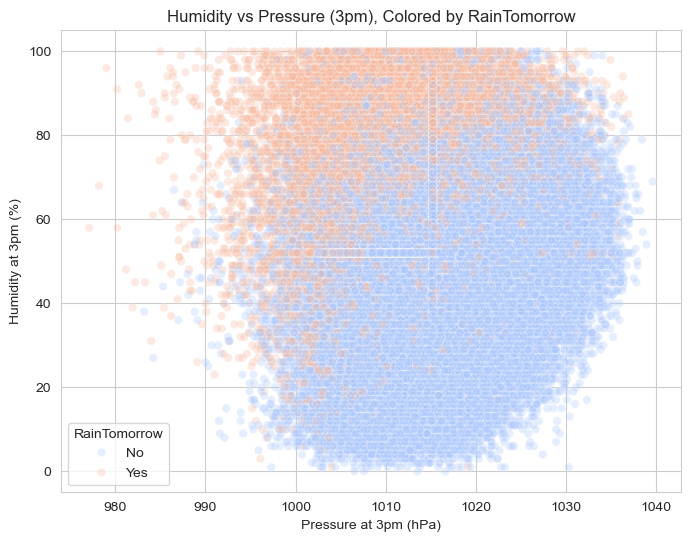

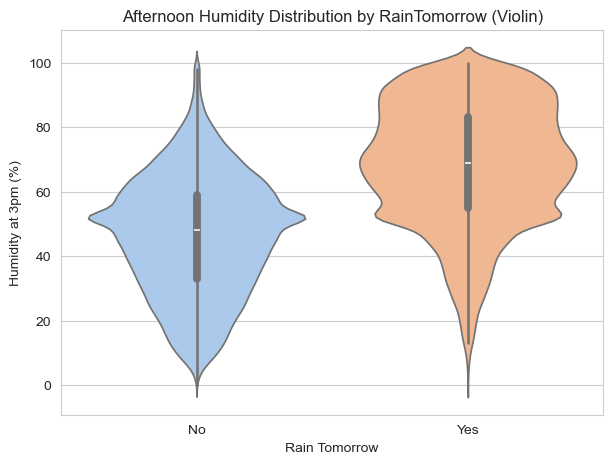

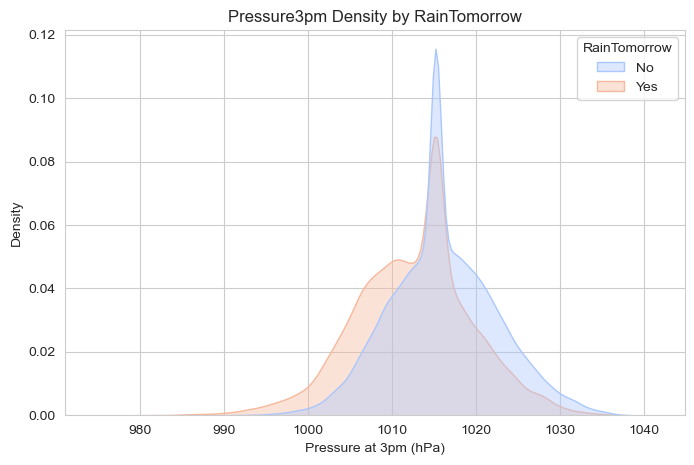

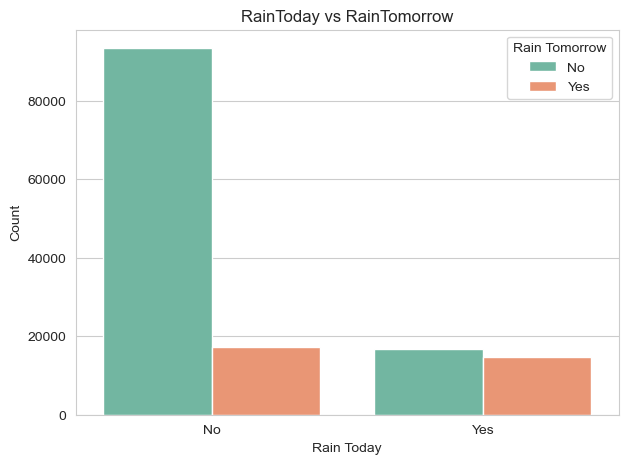

RainTomorrow         No        Yes
RainToday                         
No            84.395600  15.604400
Yes           53.594023  46.405977


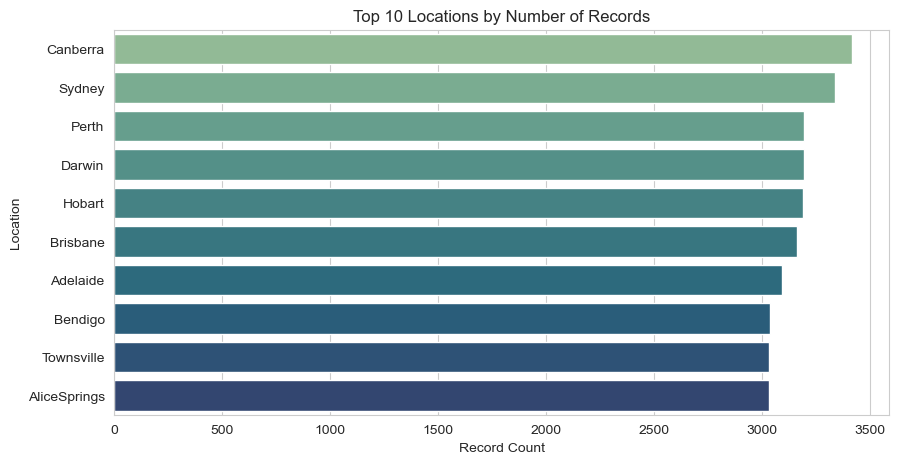

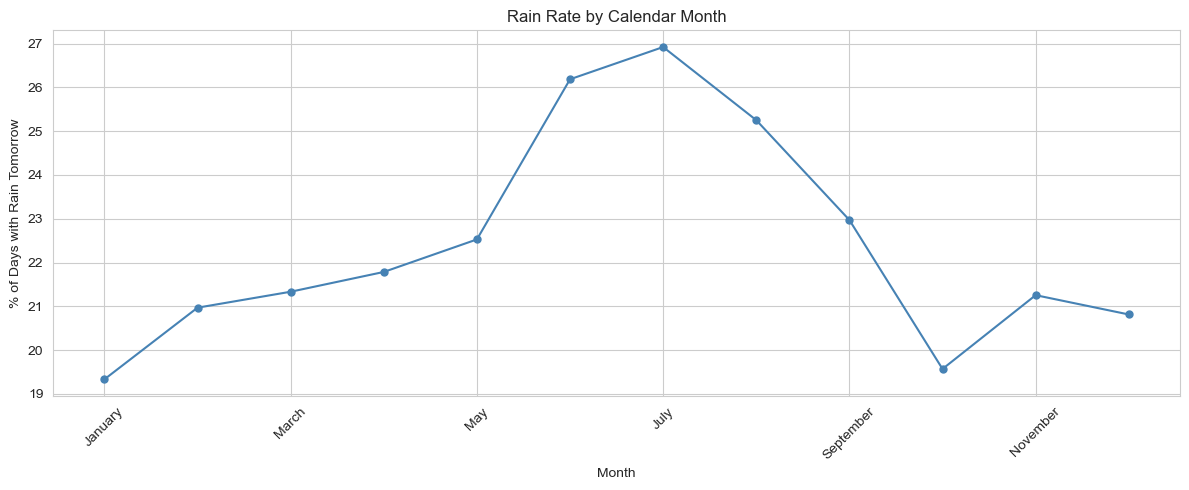

Month
January      19.332869
February     20.969121
March        21.333231
April        21.784893
May          22.527767
June         26.184519
July         26.920791
August       25.250808
September    22.970472
October      19.569637
November     21.254690
December     20.814061
Name: RainTomorrow, dtype: float64


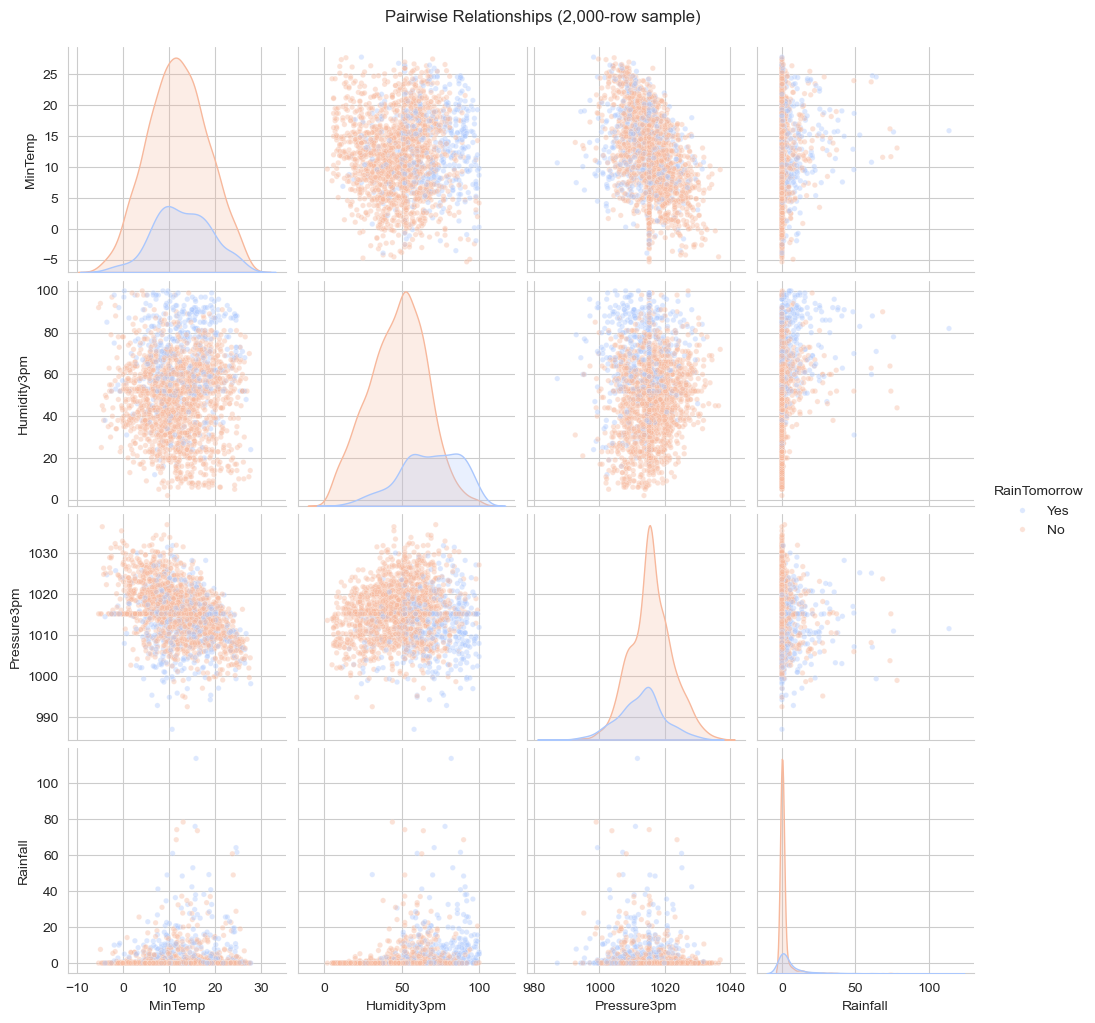

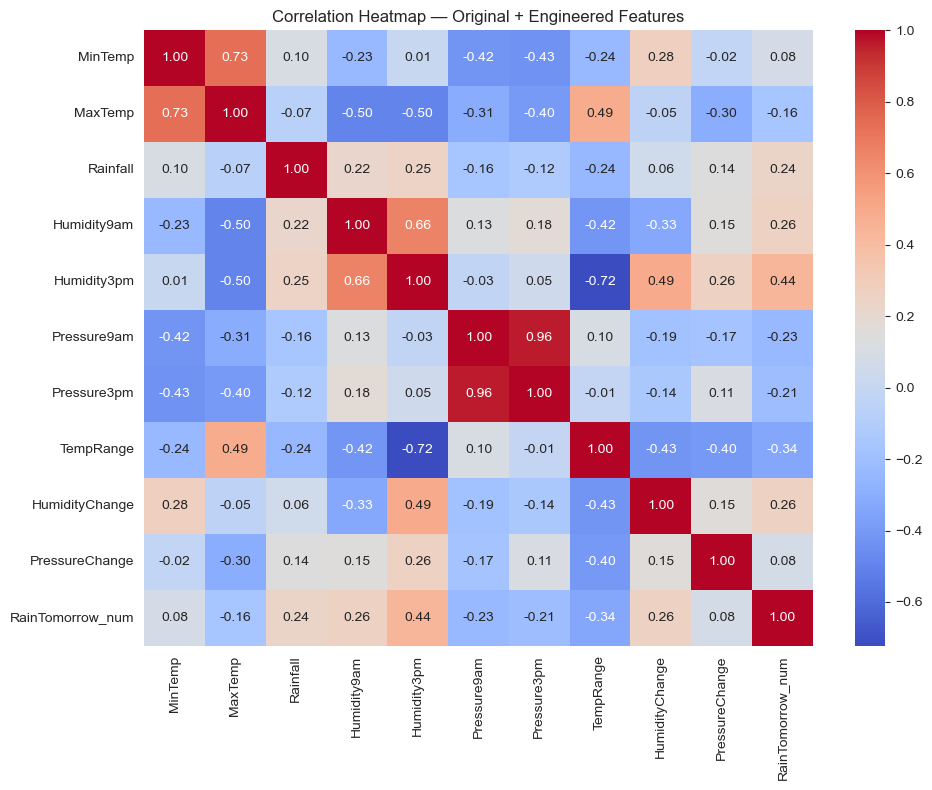

           Feature     Score
9      Humidity3pm  0.114705
16       TempRange  0.067107
4         Sunshine  0.059873
13        Cloud3pm  0.058553
2         Rainfall  0.054933
12        Cloud9am  0.042056
17  HumidityChange  0.038533
8      Humidity9am  0.037854
10     Pressure9am  0.029732
5    WindGustSpeed  0.025606
11     Pressure3pm  0.024582
15         Temp3pm  0.019658
1          MaxTemp  0.015083
3      Evaporation  0.010844
18  PressureChange  0.010795
7     WindSpeed3pm  0.007572
6     WindSpeed9am  0.006307
0          MinTemp  0.006103
14         Temp9am  0.000979


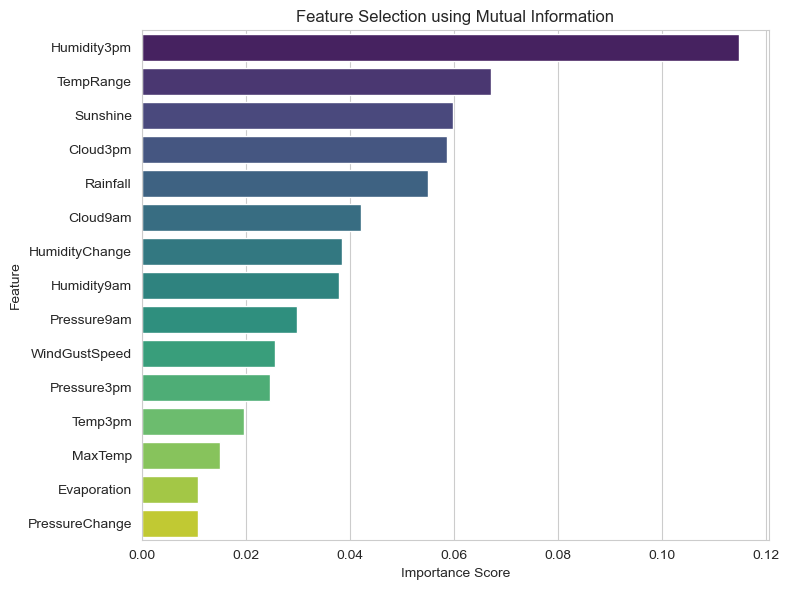


✅ FEATURE ENGINEERING & VISUALIZATION COMPLETE


In [2]:
# ==============================================================================
# PHASE 2: FEATURE ENGINEERING & DATA VISUALIZATION — WEATHER PREDICTION PROJECT
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


# ------------------------------------------------------------------------------
# STEP 1: LOAD DATASET & LIGHT CLEANING
# Reloading from the raw CSV (not the fully-encoded Phase 1 output) because
# visualization is far more readable with actual labels (Location names,
# Month names, Yes/No) instead of Label-Encoded integers.
# ------------------------------------------------------------------------------
df = pd.read_csv('weatherAUS.csv')
print(f"Shape: {df.shape}")

df = df.drop_duplicates()
df.dropna(subset=['RainTomorrow'], inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


# ------------------------------------------------------------------------------
# STEP 2: FEATURE ENGINEERING
# ------------------------------------------------------------------------------

# --- 2a. Date & Time Extraction ---
# weatherAUS.csv dates are DD/MM/YYYY — pass format explicitly to avoid
# pandas misreading dates like 13/12/2008 as an invalid MM/DD/YYYY value.
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month_name()

def month_to_season(month_num):
    if month_num in [12, 1, 2]:
        return 'Summer'      # Southern Hemisphere (Australia)
    elif month_num in [3, 4, 5]:
        return 'Autumn'
    elif month_num in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df['Season'] = df['Date'].dt.month.apply(month_to_season)

print(df[['Date', 'Month', 'Season']].head())

# --- 2b. Derived Numeric Features ---
df['TempRange'] = df['MaxTemp'] - df['MinTemp']
df['HumidityChange'] = df['Humidity3pm'] - df['Humidity9am']
df['PressureChange'] = df['Pressure3pm'] - df['Pressure9am']

print(df[['TempRange', 'HumidityChange', 'PressureChange']].describe())

# --- 2c. Removing a Redundant Feature ---
# Date's useful signal (seasonality) is now captured in Month/Season.
# The raw date string adds no further value, so it's dropped here.
df.drop(columns=['Date'], inplace=True)
print(f"Shape after dropping Date: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


# ------------------------------------------------------------------------------
# STEP 3: DATA VISUALIZATION
# Each plot includes a title, axis labels, and a brief interpretation.
# ------------------------------------------------------------------------------

# --- 3a. Target Class Distribution (Count Plot) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='RainTomorrow', hue='RainTomorrow', data=df, palette='Set2', legend=False)
plt.title('RainTomorrow Class Distribution')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Count')
plt.show()

print(df['RainTomorrow'].value_counts())
# Interpretation: The dataset is heavily imbalanced — far more "No Rain" days
# than "Rain" days (110,316 vs 31,877). This count differs from Phase 1's
# post-outlier-removal count (95,420 / 18,228) because this notebook works
# from the lightly-cleaned dataset without IQR outlier removal on Rainfall —
# both are correct for their respective pipeline stage.


# --- 3b. Rainfall Distribution (Histogram + KDE) ---
plt.figure(figsize=(8, 5))
sns.histplot(df[df['Rainfall'] < 50]['Rainfall'], bins=30, kde=True, color='skyblue')
plt.title('Rainfall Distribution (values under 50mm for readability)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()
# Interpretation: Rainfall is heavily right-skewed — most days record 0mm or
# close to it, with a long tail of rarer heavier-rain days. Confirms why the
# IQR outlier treatment in Phase 1 was necessary before scaling.


# --- 3c. Pressure3pm by RainTomorrow (Box Plot) ---
plt.figure(figsize=(7, 5))
sns.boxplot(x='RainTomorrow', y='Pressure3pm', hue='RainTomorrow', data=df, palette='coolwarm', legend=False)
plt.title('Afternoon Pressure by RainTomorrow')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Pressure at 3pm (hPa)')
plt.show()
# Interpretation: Median Pressure3pm is visibly lower on days followed by
# rain — consistent with the rule that falling/low pressure precedes rain.


# --- 3d. Humidity3pm by RainTomorrow (Box Plot) ---
plt.figure(figsize=(7, 5))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', hue='RainTomorrow', data=df, palette='coolwarm', legend=False)
plt.title('Afternoon Humidity by RainTomorrow')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Humidity at 3pm (%)')
plt.show()
# Interpretation: Higher humidity at 3pm is associated with a greater
# likelihood of rain the next day — the "Yes" group sits noticeably higher.


# --- 3e. Rain Probability by Season (Bar Plot) ---
season_rain = df.groupby('Season')['RainTomorrow'].apply(lambda x: (x == 'Yes').mean() * 100)
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
season_rain = season_rain.reindex(season_order)

plt.figure(figsize=(7, 5))
sns.barplot(x=season_rain.index, y=season_rain.values, hue=season_rain.index, palette='viridis', legend=False)
plt.title('Rain Probability by Season')
plt.xlabel('Season')
plt.ylabel('% of Days with Rain Tomorrow')
plt.show()

print(season_rain)
# Interpretation: Winter shows the highest rain probability (26.1%), Summer
# the lowest (20.3%) — confirmed directly from the printed values, validating
# Season as a genuinely useful engineered feature.


# --- 3f. Humidity3pm vs Pressure3pm (Scatter, colored by target) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Pressure3pm', y='Humidity3pm', hue='RainTomorrow', data=df, alpha=0.3, palette='coolwarm')
plt.title('Humidity vs Pressure (3pm), Colored by RainTomorrow')
plt.xlabel('Pressure at 3pm (hPa)')
plt.ylabel('Humidity at 3pm (%)')
plt.show()
# Interpretation: Rainy days cluster toward the lower-pressure, higher-humidity
# region — the two features combine to separate classes better than either alone.


# --- 3g. Humidity3pm by RainTomorrow (Violin Plot) ---
plt.figure(figsize=(7, 5))
sns.violinplot(x='RainTomorrow', y='Humidity3pm', hue='RainTomorrow', data=df, palette='pastel', legend=False)
plt.title('Afternoon Humidity Distribution by RainTomorrow (Violin)')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Humidity at 3pm (%)')
plt.show()
# Interpretation: Confirms the box plot finding but also shows the full
# density — the "Yes" class has a wider spread at high humidity values.


# --- 3h. Pressure3pm Distribution — Overlaid KDE by Class ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Pressure3pm', hue='RainTomorrow', fill=True, common_norm=False, alpha=0.4, palette='coolwarm')
plt.title('Pressure3pm Density by RainTomorrow')
plt.xlabel('Pressure at 3pm (hPa)')
plt.ylabel('Density')
plt.show()
# Interpretation: The two density curves peak at different pressure values
# and overlap in the middle — informative but not a perfect single-feature separator.


# --- 3i. RainToday vs RainTomorrow (Categorical vs Categorical) ---
plt.figure(figsize=(7, 5))
sns.countplot(x='RainToday', hue='RainTomorrow', data=df, palette='Set2')
plt.title('RainToday vs RainTomorrow')
plt.xlabel('Rain Today')
plt.ylabel('Count')
plt.legend(title='Rain Tomorrow')
plt.show()

print(pd.crosstab(df['RainToday'], df['RainTomorrow'], normalize='index') * 100)
# Interpretation: Strong persistence effect — rain rate jumps from 15.6% when
# it didn't rain today to 46.4% when it did, confirming RainToday is one of
# the most informative single features in the dataset.


# --- 3j. Top 10 Locations by Record Count (Bar Plot) ---
top_locations = df['Location'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index, palette='crest', legend=False)
plt.title('Top 10 Locations by Number of Records')
plt.xlabel('Record Count')
plt.ylabel('Location')
plt.show()
# Interpretation: Record counts are reasonably balanced across the most-
# represented locations, so Location is unlikely to be dominated by one city.


# --- 3k. Rain Rate by Calendar Month (Line Plot) ---
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_rain = df.groupby('Month')['RainTomorrow'].apply(lambda x: (x == 'Yes').mean() * 100)
monthly_rain = monthly_rain.reindex(month_order)

plt.figure(figsize=(12, 5))
monthly_rain.plot(kind='line', color='steelblue', marker='o', markersize=5)
plt.title('Rain Rate by Calendar Month')
plt.xlabel('Month')
plt.ylabel('% of Days with Rain Tomorrow')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_rain)
# Interpretation: A clear seasonal cycle in rain probability across the
# calendar year — not a flat, random pattern. Reinforces Month/Season as
# genuinely predictive rather than arbitrary categories.


# --- 3l. Pairwise Relationships Across Key Features (Pair Plot) ---
pairplot_cols = ['MinTemp', 'Humidity3pm', 'Pressure3pm', 'Rainfall', 'RainTomorrow']
sample_df = df[pairplot_cols].sample(2000, random_state=42)

sns.pairplot(sample_df, hue='RainTomorrow', palette='coolwarm', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairwise Relationships (2,000-row sample)', y=1.02)
plt.show()
# Interpretation: Humidity3pm and Pressure3pm show the clearest visual
# separation between classes among this subset, matching earlier plots.


# --- 3m. Correlation Heatmap — Including New Features ---
corr_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
             'Pressure9am', 'Pressure3pm', 'TempRange', 'HumidityChange', 'PressureChange']

df_corr = df.copy()
df_corr['RainTomorrow_num'] = df_corr['RainTomorrow'].map({'No': 0, 'Yes': 1})

plt.figure(figsize=(10, 8))
corr_matrix = df_corr[corr_cols + ['RainTomorrow_num']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap — Original + Engineered Features')
plt.tight_layout()
plt.show()
# Interpretation: Humidity3pm shows the strongest linear correlation with
# RainTomorrow (0.44), with TempRange as the second-strongest (-0.34) — a
# genuinely useful engineered feature, not a weak one. PressureChange and
# MinTemp show the weakest correlation (0.08 each) among the features
# checked here. Compare against the Mutual Information ranking in Step 4
# below: Sunshine, Cloud3pm, and Cloud9am rank in the top 6 there despite
# not being included in this heatmap's feature list.
#
# Also worth noting for Phase 3: Pressure9am/Pressure3pm are correlated with
# each other at 0.96, and MinTemp/MaxTemp at 0.73 — expected, since morning
# and afternoon readings naturally track each other, but worth considering
# if redundant-feature reduction is done later. TempRange and Humidity3pm are
# also correlated with each other at -0.72, despite both being strong
# individual predictors of RainTomorrow.


# ------------------------------------------------------------------------------
# STEP 4: FEATURE SELECTION (MUTUAL INFORMATION / SELECTKBEST)
# Required by the task brief. Captures non-linear relationships a plain
# Pearson correlation (used above) can miss.
# ------------------------------------------------------------------------------
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial

df_fs = df.copy()
df_fs['RainTomorrow'] = df_fs['RainTomorrow'].map({'No': 0, 'Yes': 1})

X = df_fs.select_dtypes(include=['number']).drop(columns=['RainTomorrow'], errors='ignore')
y = df_fs['RainTomorrow']

# random_state fixed for reproducibility — mutual_info_classif uses an internal
# randomized estimator, so scores can shift slightly between runs without it.
mi_scorer = partial(mutual_info_classif, random_state=42)
selector = SelectKBest(score_func=mi_scorer, k=10)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(feature_scores)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_scores.head(15), x='Score', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Feature Selection using Mutual Information')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
# Interpretation: Humidity3pm (0.115) and TempRange (0.067) rank 1st and 2nd
# — matching the correlation heatmap exactly, giving two independent forms
# of confirmation. Sunshine (0.060), Cloud3pm (0.059), and Cloud9am (0.042)
# rank 3rd, 4th, and 6th respectively — genuinely useful features that
# weren't checked in the correlation heatmap above. PressureChange (0.011),
# MinTemp (0.006), and Temp9am (0.001, the single lowest) rank at the bottom
# in both methods, making them the strongest candidates to drop before
# Phase 3 modeling if further feature reduction is needed.

print("\n✅ FEATURE ENGINEERING & VISUALIZATION COMPLETE")